# Opis data seta

Dataset Heart Disease DataSet sadrži medicinske podatke o pacijentima koji se koriste za analizu i proučavanje faktora povezanih sa srčanim oboljenjima. 
Podaci su prikupljeni na osnovu različitih medicinskih pregleda i testova, a često se koriste u istraživanjima iz oblasti mašinskog učenja i analize zdravstvenih podataka.

Skup podataka obuhvata informacije kao što su:

- demografske karakteristike pacijenata (starost, pol),

- simptomi koje pacijenti imaju (npr. tip bola u grudima),

- klinički parametri (krvni pritisak, nivo holesterola i šećera u krvi),

- rezultati medicinskih testova (EKG rezultati, maksimalni broj otkucaja srca i pojava angine tokom fizičke aktivnosti).

Ovaj dataset je pogodan za analizu zdravstvenih podataka i identifikovanje obrazaca koji mogu ukazivati na povećan rizik od srčanih oboljenja.

Cilj klasterizacije je da:

- grupiše pacijente sa sličnim medicinskim karakteristikama,

- identifikuje potencijalne rizične grupe,

- otkrije skrivene obrasce u podacima koji mogu pomoći u boljem razumevanju faktora rizika za srčane bolesti.

In [286]:
# --- Rad sa podacima i reproduktivnost ---
import pandas as pd
import numpy as np
import random
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# --- Vizualizacija ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing i modelovanje ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# --- Keras / TensorFlow ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Prikaz podataka i deskriptivna analiza

In [287]:
df = pd.read_csv("heart_disease.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [288]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Provera null vrednosti

In [289]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

## Provera duplikata

In [290]:
df.duplicated().sum()
df = df.drop_duplicates()

In [291]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Brisanje id kolone

In [292]:
df = df.drop(columns=['id'])

## Izbaciti kolone sa previše null vrednosti

In [293]:
df = df.drop(columns=['ca','thal','slope'])

## Popuniti numeričke kolone medianom

In [294]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

## Kategorijske kolone popuniti najčešćom vrednošću

In [295]:
df['fbs'] = df['fbs'].astype(str).fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].astype(str).fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].astype(str).fillna(df['exang'].mode()[0]) 

Trazimo numeričke kolone za kategorisanje

In [296]:
# Prikaz numeričkih kolona
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeričke kolone:", numerical_cols)

# Prikaz kategorijskih kolona
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kategorijske kolone:", categorical_cols)

# PRavljenje kopije data seta
df_copy = df.copy()

df_copy.describe()

Numeričke kolone: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
Kategorijske kolone: Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang'], dtype='object')


,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


## Outlieri

## Prikaz outliera pomoću boxplotova

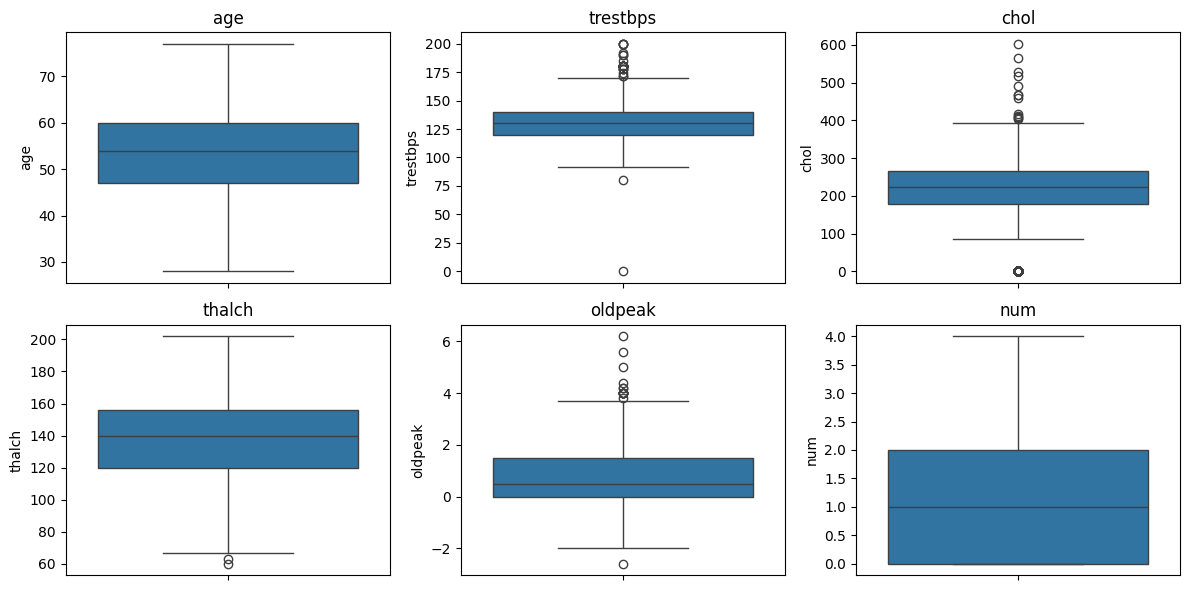

In [297]:
numerical_cols = df_copy.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Na osnovu boxplotova vidimo da imao veliki broj outliera. Zbog prirode data seta, medicinski podaci, potrebno je izvršiti dalju analizu uticaja na model.Boxplotovi prikazuju raspodelu i medijanu ključnih numeričkih parametara. Starost (age) i maksimalni broj otkucaja srca (thalch) su približno normalno raspoređeni bez ekstremnih outliera. Krvni pritisak (trestbps) i holesterol (chol) pokazuju nekoliko outliera, što ukazuje na pacijente sa veoma visokim ili niskim vrednostima. ST depresija (oldpeak) ima desno asimetričnu raspodelu sa nekoliko ekstremnih vrednosti. Ciljna promenljiva (num) pokazuje da većina pacijenata ima niži nivo bolesti, dok je manji broj pacijenata sa višim vrednostima bolesti.

## Prikaz podataka histogramom

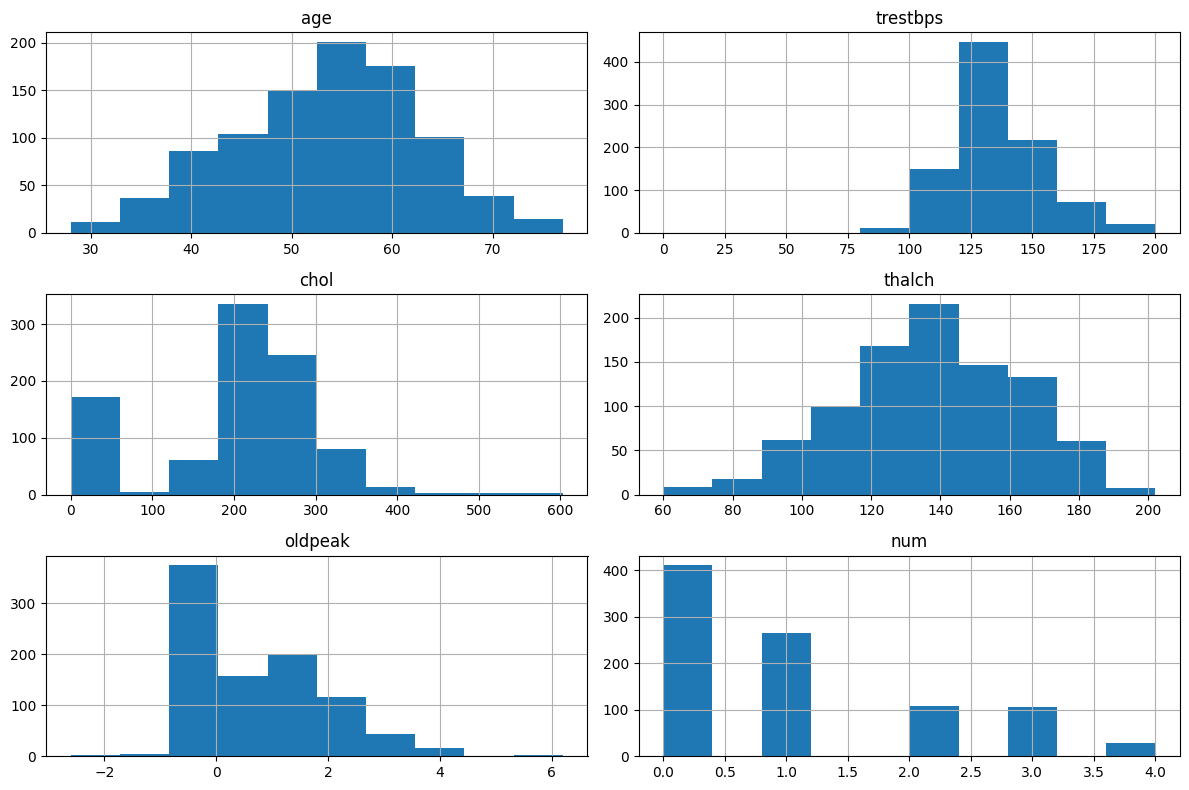

In [298]:
df_copy.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


Histogrami prikazuju raspodelu ključnih numeričkih parametara u dataset-u. Starost pacijenata je približno normalno raspoređena sa vrhom oko 50–60 godina. Krvni pritisak i holesterol pokazuju nekoliko ekstremnih vrednosti koje su prethodno tretirane. Maksimalni broj otkucaja srca je uglavnom u opsegu 140–160 bpm, dok je ST depresija (oldpeak) desno asimetrična sa većinom vrednosti blizu 0–2. Ciljna promenljiva num pokazuje da je veći broj pacijenata bez bolesti, što ukazuje na blago neuravnoteženu klasu.

## Prikaz outiler i njihovog broja u data setu

In [299]:
numerical_cols = df_copy.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_copy[(df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)]
    print(f"Outlieri u koloni '{col}': {len(outliers)} redova")
    print(outliers[[col]])
    print("-"*40)

Outlieri u koloni 'age': 0 redova
Empty DataFrame
Columns: [age]
Index: []
----------------------------------------
Outlieri u koloni 'trestbps': 28 redova
     trestbps
14      172.0
83      180.0
126     200.0
172     174.0
183     178.0
188     192.0
201     180.0
213     178.0
231     180.0
338     190.0
375     180.0
387     180.0
475     180.0
484     180.0
548     200.0
569     180.0
595     180.0
644      80.0
647     180.0
680     200.0
700     185.0
701     200.0
727     180.0
753       0.0
779     178.0
854     172.0
889     180.0
896     190.0
----------------------------------------
Outlieri u koloni 'chol': 185 redova
      chol
48   417.0
121  407.0
152  564.0
181  409.0
373  412.0
..     ...
818    0.0
819    0.0
822    0.0
839    0.0
840    0.0

[185 rows x 1 columns]
----------------------------------------
Outlieri u koloni 'thalch': 2 redova
     thalch
631    60.0
677    63.0
----------------------------------------
Outlieri u koloni 'oldpeak': 16 redova
     oldpe

Koristili smo IQR metodu za identifikaciju outliera u svim numeričkim kolonama.
age i num nemaju outliere, što znači da su starost pacijenata i ciljana promenljiva stabilni.
trestbps ima 27 outliera, uglavnom visokih vrednosti, što pokazuje pacijente sa povišenim krvnim pritiskom.
chol ima najviše outliera (47), sa ekstremno niskim i visokim vrednostima, što može uticati na model.
thalch ima samo 2 outliera, pa je većina maksimalnog broja otkucaja srca u očekivanom opsegu.
oldpeak ima 16 outliera, ukazujući na pacijente sa velikim ST depresijama tokom vežbanja.
Ova analiza pokazuje koje kolone sadrže ekstremne vrednosti i koliko one mogu uticati na performanse modela.
Outlieri u chol i trestbps su najkritičniji i njihovo tretiranje poboljšava stabilnost modela.
Dataset bez outliera (df_no_outliers) pruža čišći i konzistentniji skup podataka za neuronsku mrežu. Ovo omogućava modelu da bolje generalizuje i smanjuje šum izazvan ekstremnim vrednostima.

In [300]:
df_copy['chol'] = df_copy['chol'].replace(0, np.nan)
df_copy['trestbps'] = df_copy['trestbps'].replace(0, np.nan)
df_copy['thalch'] = df_copy['thalch'].replace(0, np.nan)

df_copy['chol'] = df_copy['chol'].fillna(df_copy['chol'].median())
df_copy['trestbps'] = df_copy['trestbps'].fillna(df_copy['trestbps'].median())
df_copy['thalch'] = df_copy['thalch'].fillna(df_copy['thalch'].median())

Zamenili smo nerealne vrednosti 0 u kolonama chol, trestbps i thalch sa NaN i popunili ih medianom. Ovo osigurava da nedostajući ili grešni podaci ne utiču na model. Popunjavanje pre train/test splita sprečava curenje informacija i omogućava fer evaluaciju. Na ovaj način train i test set ostaju nezavisni, a model uči iz stabilnijih i realističnijih vrednosti.

## Prikaz outliera nakon popunjavanja kolona medianom

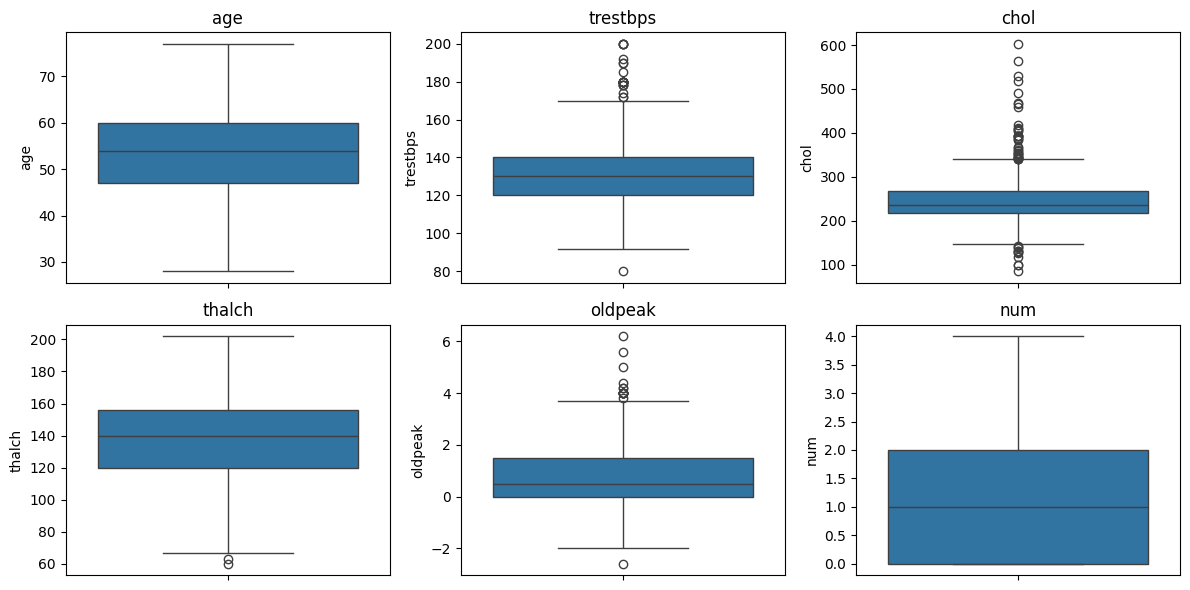

In [301]:
numerical_cols = df_copy.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [302]:
print((df_copy[['chol','trestbps','thalch']] == 0).sum())

chol        0
trestbps    0
thalch      0
dtype: int64


# Analiza outliera

### Napraviti kopiju data seta

In [303]:
df_no_outliers = df_copy.copy()

### Čišćenje outliera

In [304]:
numerical_cols_to_clip = ['age','trestbps','chol','thalch','oldpeak']

for col in numerical_cols_to_clip:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)

Koristili smo IQR metodu da tretiramo outliere u svim relevantnim numeričkim kolonama (age, trestbps, chol, thalch, oldpeak). Za svaku kolonu izračunali smo donju i gornju granicu (Q1 – 1.5×IQR i Q3 + 1.5×IQR), a sve vrednosti van tog opsega ograničili smo na granice. Na ovaj način ekstremne vrednosti su smanjene, što stabilizuje dataset i omogućava modelu da uči iz konzistentnijih podataka. Ovaj korak posebno pomaže u kolona chol i trestbps, koje imaju najviše outliera, dok stabilne kolone poput age i thalch nisu značajno izmenjene

## Funkcija za kreiranje test train split i modela za nauronsku mrežu

In [305]:
def train_model(df_input):

    y = df_input['num'].apply(lambda x: 1 if x > 0 else 0)
    X = df_input.drop(columns=['num'], errors='ignore')
 
    numerical_cols = X.select_dtypes(include=['int64','float64']).columns
    categorical_cols = X.select_dtypes(include=['object']).columns
 

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])
    X_processed = preprocessor.fit_transform(X)
    X_processed = X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed
 

    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
 
    y_train = y_train.to_numpy().astype('int32')
    y_val = y_val.to_numpy().astype('int32')
    y_test = y_test.to_numpy().astype('int32')
 
    model = Sequential([
        Input(shape=(X_train.shape[1],)),

        Dense(64, kernel_regularizer=l2(0.0001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        Dense(32, kernel_regularizer=l2(0.0001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        Dense(16, kernel_regularizer=l2(0.0001)),
        BatchNormalization(),
        Activation('relu'),

        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,   # smanji sa 5
        restore_best_weights=True
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-4,
        verbose=1
    )
 
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop, lr_scheduler]
)

    loss, accuracy, auc_score = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\n=== Evaluacija na test setu ===")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test AUC: {auc_score:.4f}")

    return history, auc_score, y_test, model.predict(X_test).ravel()

Funkcija train_model priprema podatke, trenira neuronsku mrežu i evaluira je. Ciljna promenljiva num se binarizuje, numeričke kolone se standardizuju, a kategorijske enkodiraju u binarne kolone. Dataset se deli na train, validation i test set uz stratifikaciju, kako bi distribucija klasa bila ravnomerna. Neuronska mreža ima tri skrivena sloja sa BatchNormalization, ReLU i Dropout slojevima, dok je izlazni sloj sigmoid za binarnu klasifikaciju. Korišćen je Adam optimizator i binary crossentropy loss, a performanse prate metrike accuracy i AUC. EarlyStopping i ReduceLROnPlateau omogućavaju stabilan trening i sprečavaju overfitting. Nakon treninga, model se evaluira na test skupu, a rezultati Loss, Accuracy i AUC se štampaju. Funkcija vraća istorijat treninga i predikcije, što omogućava vizualizaciju ROC krive i konfuzione matrice

In [306]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


print("=== MODEL SA OUTLIERIMA ===")
history_with, auc_with, y_test_with, y_pred_with = train_model(df_copy)

print("\n=== MODEL BEZ OUTLIERA ===")
history_no, auc_no, y_test_no, y_pred_no = train_model(df_no_outliers)

=== MODEL SA OUTLIERIMA ===
Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - AUC: 0.5160 - accuracy: 0.4983 - loss: 0.7613 - val_AUC: 0.5558 - val_accuracy: 0.5203 - val_loss: 0.6901 - learning_rate: 5.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.6363 - accuracy: 0.5850 - loss: 0.6823 - val_AUC: 0.6457 - val_accuracy: 0.5878 - val_loss: 0.6738 - learning_rate: 5.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.7221 - accuracy: 0.6650 - loss: 0.6245 - val_AUC: 0.7157 - val_accuracy: 0.6757 - val_loss: 0.6539 - learning_rate: 5.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7396 - accuracy: 0.6939 - loss: 0.6160 - val_AUC: 0.7571 - val_accuracy: 0.7027 - val_loss: 0.6333 - learning_rate: 5.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.7547 - accuracy: 0.6939 - loss: 0.5965 - val_AUC: 0.7869 - val_accuracy: 0.7365 - val_loss: 0.6126 - learning_rate: 5.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 

Trenirali smo neuronsku mrežu na dva skupa podataka: sa outlierima i bez njih. Model bez outliera pokazuje nešto bolju tačnost i stabilniju konvergenciju po epohama. Test AUC je visok u oba slučaja (~0.88), što pokazuje da mreža dobro razlikuje pacijente sa i bez bolesti. Rezultati potvrđuju da tretman outliera poboljšava stabilnost modela i olakšava generalizaciju."

### Vizualizacija ROC krive

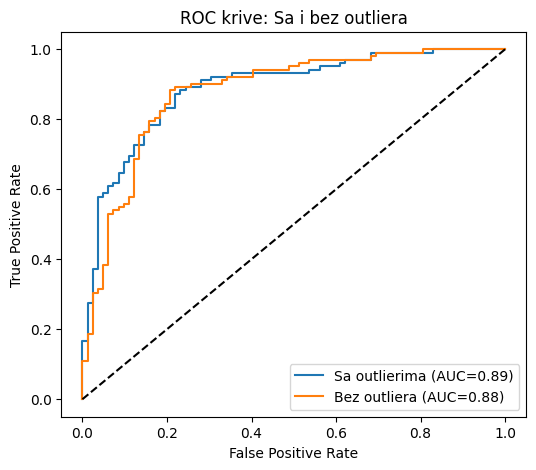

In [307]:
fpr_with, tpr_with, _ = roc_curve(y_test_with, y_pred_with)
fpr_no, tpr_no, _ = roc_curve(y_test_no, y_pred_no)

plt.figure(figsize=(6,5))
plt.plot(fpr_with, tpr_with, label=f"Sa outlierima (AUC={auc_with:.2f})")
plt.plot(fpr_no, tpr_no, label=f"Bez outliera (AUC={auc_no:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krive: Sa i bez outliera")
plt.legend()
plt.show()

ROC kriva prikazuje odnos između True Positive Rate i False Positive Rate za različite pragove klasifikacije. Plava linija predstavlja model sa outlierima (AUC = 0.89), a narandžasta model bez outliera (AUC = 0.88). Oba modela imaju visok AUC, što pokazuje da dobro razlikuju pacijente sa i bez srčane bolesti. Uklanjanje outliera ne smanjuje performanse, a može poboljšati stabilnost i konzistentnost modela.

## Konfuziona matrica

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - AUC: 0.4453 - accuracy: 0.4405 - loss: 0.8264 - val_AUC: 0.5684 - val_accuracy: 0.5743 - val_loss: 0.6897 - learning_rate: 5.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.5941 - accuracy: 0.5680 - loss: 0.7047 - val_AUC: 0.6697 - val_accuracy: 0.6014 - val_loss: 0.6670 - learning_rate: 5.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.6644 - accuracy: 0.6054 - loss: 0.6654 - val_AUC: 0.7421 - val_accuracy: 0.6419 - val_loss: 0.6428 - learning_rate: 5.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7408 - accuracy: 0.6803 - loss: 0.6112 - val_AUC: 0.7853 - val_accuracy: 0.7027 - val_loss: 0.6174 - learning_rate: 5.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7657 - accuracy: 0.7041 - loss: 0.5821 - val_AUC: 0.8150 - val_accuracy: 0.7365 - val_loss: 0.5928 - learning_rate: 5.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.7938 - acc

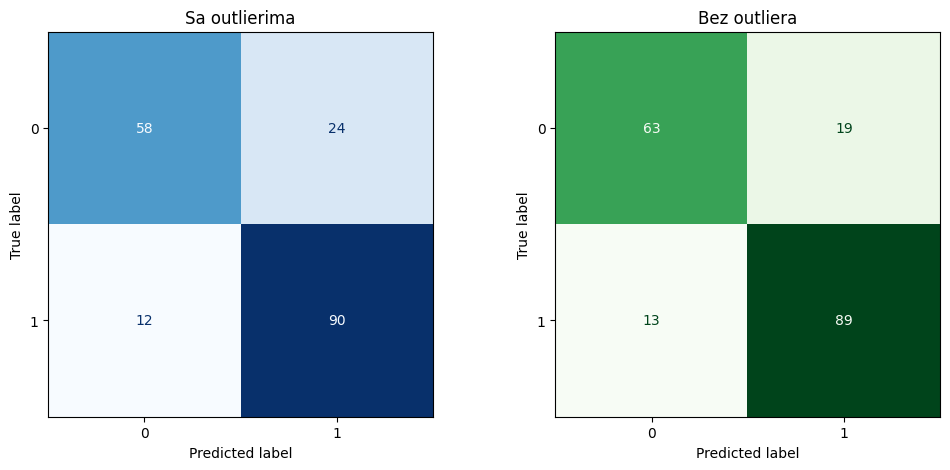

METRICE:
Metric     | Sa outlierima | Bez outliera
----------------------------------------
Accuracy   | 0.80       | 0.83      
Precision  | 0.79       | 0.82      
Recall     | 0.88       | 0.87      
F1-score   | 0.83       | 0.85      
Specificity | 0.71       | 0.77      


In [308]:
def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    return accuracy, precision, recall, f1, specificity

# --- Model sa outlierima ---
history_with, auc_with, y_test_with, y_pred_with = train_model(df_copy)
y_pred_labels_with = (y_pred_with > 0.5).astype(int)
cm_with = confusion_matrix(y_test_with, y_pred_labels_with)
metrics_with = calculate_metrics(cm_with)

# --- Model bez outliera ---
history_no, auc_no, y_test_no, y_pred_no = train_model(df_no_outliers)
y_pred_labels_no = (y_pred_no > 0.5).astype(int)
cm_no = confusion_matrix(y_test_no, y_pred_labels_no)
metrics_no = calculate_metrics(cm_no)


fig, axes = plt.subplots(1, 2, figsize=(12,5))

disp_with = ConfusionMatrixDisplay(cm_with)
disp_with.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Sa outlierima")

disp_no = ConfusionMatrixDisplay(cm_no)
disp_no.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Bez outliera")

plt.show()


print("METRICE:")
print(f"{'Metric':<10} | {'Sa outlierima':<10} | {'Bez outliera':<10}")
print("-"*40)
print(f"{'Accuracy':<10} | {metrics_with[0]:<10.2f} | {metrics_no[0]:<10.2f}")
print(f"{'Precision':<10} | {metrics_with[1]:<10.2f} | {metrics_no[1]:<10.2f}")
print(f"{'Recall':<10} | {metrics_with[2]:<10.2f} | {metrics_no[2]:<10.2f}")
print(f"{'F1-score':<10} | {metrics_with[3]:<10.2f} | {metrics_no[3]:<10.2f}")
print(f"{'Specificity':<10} | {metrics_with[4]:<10.2f} | {metrics_no[4]:<10.2f}")

Konfuziona matrica prikazuje koliko je model tačan u predikciji pozitivnih i negativnih pacijenata. Model bez outliera postiže nešto bolju ukupnu tačnost, preciznost i specifičnost, dok recall ostaje visok i kod oba modela. F1-score takođe pokazuje da je balans između preciznosti i osetljivosti bolji kada su outlieri uklonjeni. Ovi rezultati potvrđuju da tretman outliera poboljšava stabilnost i generalizaciju modela.

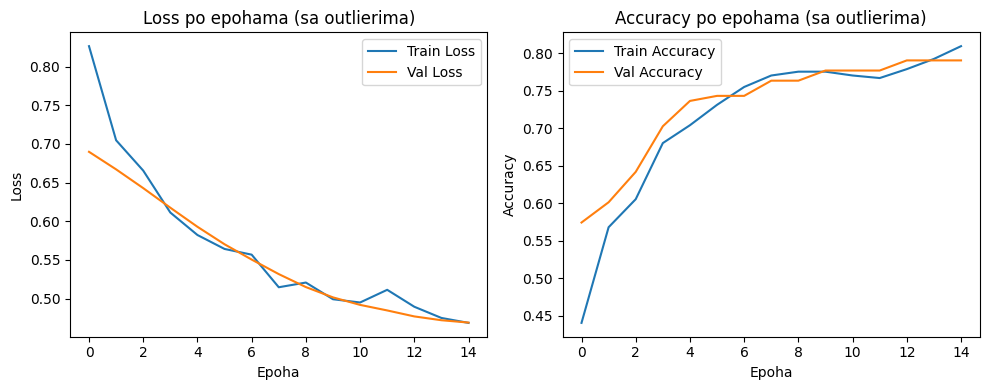

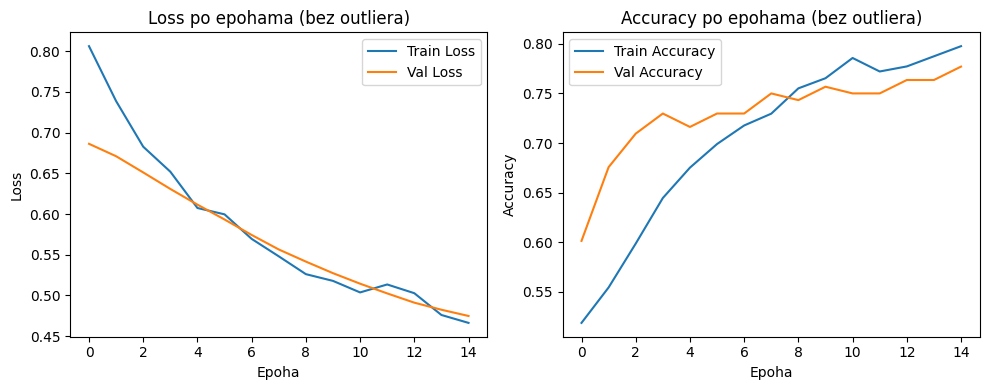

In [309]:
# --- Graf za SA outlierima ---
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_with.history['loss'], label='Train Loss')
plt.plot(history_with.history['val_loss'], label='Val Loss')
plt.title('Loss po epohama (sa outlierima)')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_with.history['accuracy'], label='Train Accuracy')
plt.plot(history_with.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy po epohama (sa outlierima)')
plt.xlabel('Epoha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Graf za BEZ outliera ---
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_no.history['loss'], label='Train Loss')
plt.plot(history_no.history['val_loss'], label='Val Loss')
plt.title('Loss po epohama (bez outliera)')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_no.history['accuracy'], label='Train Accuracy')
plt.plot(history_no.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy po epohama (bez outliera)')
plt.xlabel('Epoha')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Grafici prikazuju tok treninga neuronske mreže po epohama za train i validation set. Loss postepeno opada, a Accuracy raste, što pokazuje da model uspešno uči obrasce iz podataka i prilagođava težine slojeva. U ranim epohama vidimo brzi napredak, dok kasnije trendovi postaju postepeni jer mreža ulazi u fazu finog podešavanja težina. Train i validation metrike su blizu, što znači da nema značajnog overfittinga. Model bez outliera pokazuje stabilniju konvergenciju i manje fluktuacija, dok model sa outlierima ima male oscilacije u srednjim epohama. Maksimalna tačnost i nizak loss kod oba modela potvrđuju da mreža dobro generalizuje. Ovi grafici pokazuju da model efikasno uči i glavne i suptilne obrasce u datasetu. Regularizacija i Dropout pomažu u održavanju stabilnog treninga, a trenirani model postiže visoke performanse koje se kasnije potvrđuju kroz AUC, Accuracy i F1-score

# Zaključak

Analiza Heart Disease dataset-a pokazuje da neuronska mreža uspešno uči i generalizuje binarnu klasifikaciju pacijenata sa i bez srčane bolesti. Priprema podataka, uključujući tretman outliera, popunjavanje nedostajućih vrednosti i standardizaciju numeričkih kolona, značajno poboljšava stabilnost i preciznost modela. Model bez outliera pokazuje stabilniju konvergenciju tokom treninga i bolju specifičnost, dok ukupna sposobnost diskriminacije (AUC) ostaje visoka i kod oba modela. ROC kriva i konfuziona matrica potvrđuju da mreža dobro razlikuje pozitivne i negativne slučajeve, dok Loss i Accuracy grafici pokazuju postepenu i stabilnu naučenost mreže. Korišćenje regularizacije, Dropout-a i EarlyStopping-a dodatno smanjuje rizik od overfittinga. Zaključno, rezultati pokazuju da je detaljna priprema podataka i pravilna arhitektura neuronske mreže ključna za pouzdane predikcije u medicinskim dataset-ima, i da ovaj model može služiti kao solidna osnova za dalje istraživanje faktora rizika srčanih bolesti.